# Forecasting des ventes

## Introduction

L’objectif de ce notebook est de prédire les ventes futures à partir des données historiques.
Une meilleure prévision permetra d’optimiser les stocks, de limiter les ruptures et d’améliorer la planification logistique
Nous allons dans un premier temps analyser les séries temporelles, puis construire un modèle de prédiction.

## Analyse de la série temporelle

In [2]:
import pandas as pd

df = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")

# Somme des ventes par jour
sales_per_day = df.iloc[:, 6:].sum(axis=0)

sales_per_day = sales_per_day.reset_index()
sales_per_day.columns = ["day", "sales"]

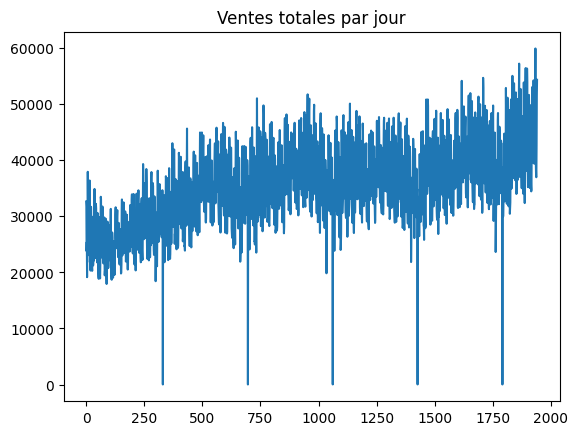

In [3]:
import matplotlib.pyplot as plt

plt.plot(sales_per_day["sales"])
plt.title("Ventes totales par jour")
plt.show()

On observe une évolution globale des ventes avec plusieurs pics négatifs réguliers.

## Création de nouvelles variables

In [4]:
sales_per_day["lag_1"] = sales_per_day["sales"].shift(1)
sales_per_day["rolling_mean_7"] = sales_per_day["sales"].rolling(7).mean()

sales_per_day = sales_per_day.dropna()

Le lag correspond aux ventes du jour précédent.
La moyenne glissante permet de lisser les variations et de capter la tendance récente.

## Modélisation

On utilise un modèle de régression pour prédire les ventes.

In [5]:
from sklearn.model_selection import train_test_split

X = sales_per_day[["lag_1", "rolling_mean_7"]]
y = sales_per_day["sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)


from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evaluation

In [6]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse)

RMSE : 6117.682240679488


Le modèle obtient une erreur quadratique moyenne (RMSE) de 6117,68.
Cette valeur représente l’écart moyen entre les ventes réelles et les ventes prédites.
Au regard de l’échelle des ventes (plusieurs dizaines de milliers d’unités par jour), cette erreur reste raisonnable.
Le modèle est donc capable de capturer une partie significative de la dynamique des ventes.

## Visualisation des prédictions

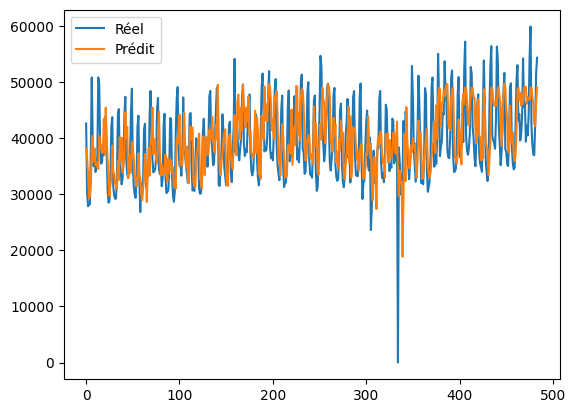

In [7]:
plt.plot(y_test.values, label="Réel")
plt.plot(y_pred, label="Prédit")
plt.legend()
plt.show()

La comparaison entre les valeurs réelles et les prédictions montre que le modèle suit globalement la tendance des ventes.
Cependant, des écarts apparaissent lors des pics de demande.
Cela s’explique par le fait que ces variations sont souvent liées à des facteurs externes non présents dans le modèle (promotions, événements, saisonnalité spécifique).
Le modèle est donc performant pour capter la tendance générale, mais moins précis sur les variations brusques.